## Question: "What line flux can I detect at N-sigma in a fixed exposure time?"

### Some NIRSpec Docs
- [Readout Patterns](https://jwst-docs.stsci.edu/jwst-near-infrared-spectrograph/nirspec-instrumentation/nirspec-detectors/nirspec-detector-readout-modes-and-patterns#gsc.tab=0)
- [Recommended Strategies](https://jwst-docs.stsci.edu/jwst-near-infrared-spectrograph/nirspec-observing-strategies/nirspec-detector-recommended-strategies#gsc.tab=0)

In [2]:
# Pandeia reference data
import os
os.environ["pandeia_refdata"] = "../../data/pandeia_data-2026.7-jwst"
os.environ["PSF_DIR"] = "../../data/pandeia_psfs-2026.7rc1-jwst"
os.environ["PYSYN_CDBS"] = "../../data/grp/redcat/trds"

# Exposure time calculator
from pandeia.engine.calc_utils import build_default_calc
from pandeia.engine.perform_calculation import perform_calculation

import matplotlib.pyplot as plt
import numpy as np

# Observing parameters
telescope = 'jwst'
instrument = 'nirspec'
mode = 'fixed_slit'
disperser = 'g395m'
filter = 'f290lp'
readout_pattern = 'nrsirs2'

# Exposure parameters 
ngroups = 190
nint = 6
nexp = 4

# Science goal
target_line_snr = 5.0 # detection threshold (sigma)
geometry = 'point' # Source geometry

# Emission line (strength is the UNKNOWN we solve for; this is just a starting guess)
name = 'H alpha'
emission_line_center = 0.6563 # rest wavelength, microns
emission_line_width = 1000 # km/s FWHM (velocity width, frame-invariant)
redshift = 5
guess_strength = 2e-18 # erg/s/cm2, starting guess for the solver

c_kms = 299792.458
obs_wavelength = emission_line_center * (1 + redshift) # observed-frame line center (um)
sigma_um = obs_wavelength * (emission_line_width / c_kms) / 2.3548  # Gaussian sigma (um)

In [3]:
def build_calc(strength):
    """Build a calc for the line at a given integrated line flux (erg/s/cm2)."""
    calc = build_default_calc(telescope, instrument, mode)
    calc['configuration']['instrument']['disperser'] = disperser
    calc['configuration']['instrument']['filter'] = filter
    calc['configuration']['detector']['readout_pattern'] = readout_pattern
    calc['configuration']['detector']['ngroup'] = ngroups
    calc['configuration']['detector']['nint'] = nint
    calc['configuration']['detector']['nexp'] = nexp
    calc['background_level'] = 'low'

    scene = calc['scene'][0]
    scene['shape']['geometry'] = geometry
    scene['spectrum']['sed'] = {'sed_type': 'no_continuum'}   # pure emission line
    scene['spectrum']['redshift'] = 0                         # line placed at observed wavelength
    scene['spectrum']['lines'] = [{
        'id': 0, 'name': name, 'emission_or_absorption': 'emission',
        'center': obs_wavelength, 'width': emission_line_width,
        'strength': strength, 'profile': 'gaussian'}]
    return calc


def integrated_line_snr(report, nsigma=3.0):
    """Continuum-subtracted integrated S/N over a fixed +/- nsigma line window."""
    wave = np.asarray(report['1d']['extracted_flux'][0])
    flux = np.asarray(report['1d']['extracted_flux'][1])
    noise = np.asarray(report['1d']['extracted_noise'][1])
    
    dist = np.abs(wave - obs_wavelength)
    line = dist <= nsigma * sigma_um
    side = (dist > nsigma * sigma_um) & (dist <= (nsigma + 4) * sigma_um)
    
    continuum = np.median(flux[side]) if side.any() else 0.0
    signal = np.sum(flux[line] - continuum)
    noise = np.sqrt(np.sum(noise[line] ** 2))
    return signal / noise


def solve_line_flux_depth(target_snr, start=1e-18, tol=0.01, max_iter=8):
    """Faintest line flux (erg/s/cm2) reaching integrated line S/N = target_snr.

    Line S/N is ~linear in line flux at the faint limit, so the multiplicative
    correction  strength *= target_snr / snr  converges in a few iterations.
    """
    strength = start
    # rep = None
    for i in range(max_iter):
        rep = perform_calculation(build_calc(strength))
        snr = integrated_line_snr(rep)
        print(f"[iter {i}] strength={strength:.3e} erg/s/cm2 -> line S/N={snr:.2f}")
        if abs(snr - target_snr) <= tol * target_snr:
            return strength, snr, rep
        strength *= target_snr / snr
    return strength, snr, rep

[iter 0] strength=2.000e-18 erg/s/cm2 -> line S/N=37.62
[iter 1] strength=2.658e-19 erg/s/cm2 -> line S/N=5.39
[iter 2] strength=2.467e-19 erg/s/cm2 -> line S/N=5.00

=== nirspec g395m/f290lp: 5.0-sigma line-flux depth ===
Fixed exposure: nexp=4, total = 35560 s (9.9 h)
Line: H alpha at z=5 (3.9378 um), width 1000 km/s
Detectable line flux (>= 5.0 sigma): 2.467e-19 erg/s/cm2 (achieved S/N 5.00)


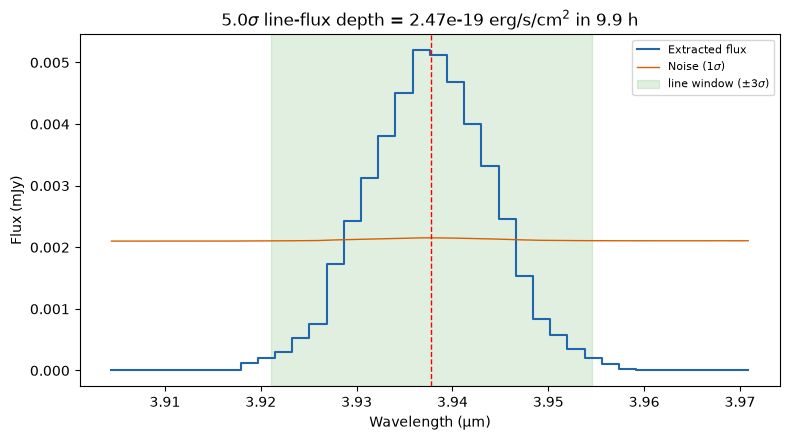

In [4]:
# Solve for the line-flux detection limit at the fixed exposure
depth, snr, report = solve_line_flux_depth(target_line_snr, start=guess_strength)
spec = report['information']['exposure_specification']

print(f"\n=== {instrument} {disperser}/{filter}: {target_line_snr}-sigma line-flux depth ===")
print(f"Fixed exposure: nexp={nexp}, total = {spec['total_exposure_time']:.0f} s "
      f"({spec['total_exposure_time']/3600:.1f} h)")
print(f"Line: {name} at z={redshift} ({obs_wavelength:.4f} um), width {emission_line_width} km/s")
print(f"Detectable line flux (>= {target_line_snr} sigma): {depth:.3e} erg/s/cm2 "
      f"(achieved S/N {snr:.2f})")

# Plot the just-detected line
wave = np.asarray(report['1d']['extracted_flux'][0])
flux = np.asarray(report['1d']['extracted_flux'][1])
noise = np.asarray(report['1d']['extracted_noise'][1])
window = np.abs(wave - obs_wavelength) <= 6 * sigma_um

plt.figure(figsize=(8, 4.5))
plt.plot(wave[window], flux[window], color='#2166ac', label='Extracted flux', drawstyle='steps-mid')
plt.plot(wave[window], noise[window], color='#d95f02', lw=1, label=r'Noise (1$\sigma$)')
plt.axvspan(obs_wavelength - 3 * sigma_um, obs_wavelength + 3 * sigma_um,
            color='green', alpha=0.12, label=r'line window ($\pm3\sigma$)')
plt.axvline(obs_wavelength, color='red', ls='--', lw=1)
plt.xlabel('Wavelength (µm)')
plt.ylabel('Flux (mJy)')
plt.title(f'{target_line_snr}$\\sigma$ line-flux depth = {depth:.2e} erg/s/cm$^2$ '
          f'in {spec["total_exposure_time"]/3600:.1f} h')
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()